In [1]:
import re
import numpy as np
import pandas as pd
import collections
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("detail.csv",usecols=["Title","Author","Wechat_NN","Layer","Address","Gender",
                                         "Time","Stay","Share2Moment","Share2Friend","Read","Belong2"])
data.head()

,Title,Author,Wechat_NN,Layer,Address,Gender,Time,Stay,Share2Moment,Share2Friend,Read,Belong2
0,名匠心，设计情丨2017名匠杯设计大赛盛大启动,李玉强,A小懒猫,7,中国 天津,女,2017-08-03 22:24:04.0,0,0,0,1,香奈儿
1,名匠心，设计情丨2017名匠杯设计大赛盛大启动,李玉强,小幸运,7,云南大理,女,2017-08-03 14:34:44.0,0,0,0,2,香奈儿
2,名匠心，设计情丨2017名匠杯设计大赛盛大启动,李玉强,  妞,7,陕西西安,女,2017-08-03 22:24:04.0,0,0,0,1,香奈儿
3,名匠心，设计情丨2017名匠杯设计大赛盛大启动,李玉强,A慢热型男,7,陕西西安,女,2017-08-03 22:24:05.0,0,0,0,1,香奈儿
4,名匠心，设计情丨2017名匠杯设计大赛盛大启动,李玉强,cqy苒燕,7,浙江绍兴,女,2017-08-03 22:24:05.0,0,0,0,1,香奈儿


In [3]:
def author_detail(name):
    article=[]
    read_1=[]
    read_2=[]
    for index, row in data.iterrows():
        if row["Author"]==name:
            title=row["Title"]
            title="".join(title.split(' '))
            if title not in article:
                article.append(title)
                if row["Layer"]==1:
                    read_1.append(row["Read"])
                    read_2.append(0)
                else:
                    read_1.append(0)
                    read_2.append(row["Read"])  
            else:
                i=article.index(title)
                if row["Layer"]==1:
                    read_1[i]+=row["Read"]
                else:
                    read_2[i]+=row["Read"]

    article_data = pd.DataFrame(
        {'Title': article,
         'read_1': read_1,
         'read_2': read_2
        })
    # print(article_data.head())
    article_data.to_csv(name+".csv")
    # plt.rcParams['font.sans-serif']=['SimHei']
    # article_data.plot.scatter(x='read_1', y='read_2',label=name)
    return article_data

,Title,read_1,read_2
0,名匠杯设计大赛,17,0
1,名匠杯设计大赛征集半山壹号140平米参赛作品,1,24
2,名匠精工丨在名匠，为您家施工的到底是怎样一群人？,12,1
3,名匠装饰,2,8
4,名匠装饰感恩中国|12月17日名匠感恩答谢会钜惠来袭温暖全城,4,0
5,【沁园报】6.18端午节特别版～白沙洲地区最优楼盘！,10,450
6,中城时代～（名匠龙冬设计）,2,120
7,凯里碧桂园别墅～名匠装饰,2,28
8,名匠装饰实景样板间,2,0
9,哆啦A梦主题房间,2,44


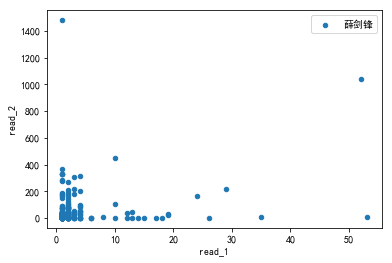

In [4]:
author_list=[u"薛剑锋",u"曾小纾",u"蒋小村",u"黄蓉"]
author_detail(author_list[0])

,Title,read_1,read_2
0,名匠精工丨在名匠，为您家施工的到底是怎样一群人？,1,0
1,名匠装饰感恩中国|12月17日名匠感恩答谢会钜惠来袭温暖全城,1,8
2,2018家装行业比负面消息更可怕：低价竞争、落井下石、吹牛成风、,4,20
3,漂亮书房设计案例，有你的菜吗,1,26
4,火了的不止《那年花开月正圆》，还有新中式风！,1,6
5,热点|《中国有嘻哈》，寻找不一样的家装freestyle！,2,17
6,特权日那么多人选择了名匠，原因就在这里！,1,3
7,玄关除了装鞋柜没别的选择吗？这样装最实用！,1,25
8,看《我的前半生》中女主角的装修小“心机”,1,8
9,真正的豪宅，应该有哪些家居系统(二),1,13


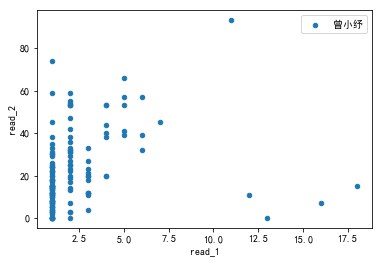

In [5]:
author_detail(author_list[1])

,Title,read_1,read_2
0,名匠精工|施工现场大巡检,2,11
1,名匠精工丨在名匠，为您家施工的到底是怎样一群人？,1,4
2,自装？亲戚装？装饰公司装？终于有让人信服的答案了,12,15
3,装修经验|夏天装修，这6个地方最爱出错，千万注意了！,4,76
4,欧式风格全景,43,8
5,火了的不止《那年花开月正圆》，还有新中式风！,1,15
6,热点|《中国有嘻哈》，寻找不一样的家装freestyle！,1,2
7,特权日那么多人选择了名匠，原因就在这里！,2,6
8,玄关除了装鞋柜没别的选择吗？这样装最实用！,1,24
9,看《我的前半生》中女主角的装修小“心机”,1,6


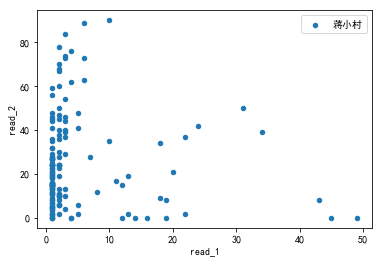

In [6]:
author_detail(author_list[2])

,Title,read_1,read_2
0,名匠精工|施工现场大巡检,1,10
1,名匠装饰感恩中国|12月17日名匠感恩答谢会钜惠来袭温暖全城,2,4
2,装修的价格与价值,6,32
3,沙发背景墙，最美不过新中式,1,31
4,火了的不止《那年花开月正圆》，还有新中式风！,1,9
5,热点|《中国有嘻哈》，寻找不一样的家装freestyle！,1,1
6,猜一猜元旦你会用什么颜色装扮自己的家,1,10
7,玄关除了装鞋柜没别的选择吗？这样装最实用！,1,33
8,真正的豪宅，应该有哪些家居系统,3,9
9,真正的豪宅，应该有哪些家居系统(一),1,20


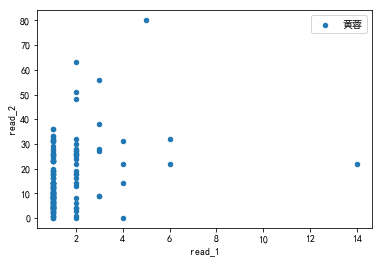

In [7]:
author_detail(author_list[3])

In [4]:
print(min(data.Time))
print(max(data.Time))

2017-05-08 09:57:22.0
2018-09-19 11:14:36.0


In [4]:
data = pd.read_csv("mingjiang/detail_new.csv",usecols=["Title","Author","Wechat_NN","Layer","Address","Gender",
                                         "Time","Stay","Share2Moment","Share2Friend","Read","Belong2"])
data = data[data.Layer==1]

,Title,Author,Wechat_NN,Layer,Address,Gender,Time,Stay,Share2Moment,Share2Friend,Read,Belong2
0,色彩搭配是家居装修的灵魂所在，不同的颜色能赋予家不同,江蓉,郑映霞,1,湖南长沙,女,2018-01-19 17:29:59.0,90,0,0,1,NaN
1,色彩搭配是家居装修的灵魂所在，不同的颜色能赋予家不同,江蓉,我是谁不重要,1,湖南长沙,男,2018-01-19 17:31:36.0,30,0,0,1,NaN
2,色彩搭配是家居装修的灵魂所在，不同的颜色能赋予家不同,江蓉,追寻,1,湖南长沙,男,2018-01-19 17:35:21.0,30,0,0,1,NaN
3,色彩搭配是家居装修的灵魂所在，不同的颜色能赋予家不同,江蓉,：,1,湖南长沙,女,2018-01-19 17:42:56.0,0,0,0,1,NaN
4,色彩搭配是家居装修的灵魂所在，不同的颜色能赋予家不同,江蓉,大米,1,大堂区,女,2018-01-19 17:55:44.0,30,0,0,1,NaN
5,色彩搭配是家居装修的灵魂所在，不同的颜色能赋予家不同,江蓉,A绿动气瓶,1,陕西西安,女,2018-01-19 22:49:10.0,0,0,0,1,NaN
6,| 简约高级灰，有气质的家！,欧发生,MJ-高级设计师 李玉龙,1,NaN,男,2017-07-03 12:25:25.0,0,0,0,1,NaN
7,| 简约高级灰，有气质的家！,欧发生,名匠装饰－张小爱－15773630720,1,湖南常德,女,2017-07-03 12:25:28.0,0,0,0,1,NaN
8,| 简约高级灰，有气质的家！,欧发生,yang_,1,中国 湖南 常德,男,2017-07-03 12:27:17.0,30,0,0,2,NaN
9,| 简约高级灰，有气质的家！,欧发生,名匠工程监理张文,1,中国 湖南 常德,男,2017-07-03 12:26:52.0,60,0,0,1,NaN


In [13]:
data_group = data.sort_values(by="Author")
data_group = data_group[["Author","Wechat_NN","Layer","Time"]]
data_group.to_csv("mingjiang/Layer_1_detail.csv")